In [1]:
import numpy as np
from pathlib import Path

from pymor.basic import *
from pymor.core.pickle import load

from RBInvParam.problems.elasticity.build import build_InstationaryModelIP

set_log_levels({
    'pymor' : 'WARN'
})

set_defaults({})


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "cm",
#     "font.size": 10,
#     'text.latex.preamble': r'\usepackage{amsfonts} \usepackage{accents} \usepackage{mathrsfs} \usepackage{bm}',
#     'figure.dpi': 200
# })

In [113]:
#WORK_DIR = Path('/home/dealii/workdir/examples/elasticity')
WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/examples/elasticity')
#SAVE_PATH = Path('/home/benedikt/Dokumente/Paper/parabolische_inverse_probleme/figures/experiments')

data_dir_path = WORK_DIR / 'dumps'

FOM_data_path = data_dir_path / '20250908_105909_FOM_IRGNM'
TR_data_path = data_dir_path / '20250909_094613_TR_IRGNM'
#TR_data_path = None





setup_path = FOM_data_path / 'setup.pkl'
optimizer_parameter_path = FOM_data_path / 'optimizer_parameter.pkl'


with open(setup_path, 'rb') as file:
    setup = load(file)

with open(optimizer_parameter_path, 'rb') as file:
    optimizer_parameter = load(file)

if not 'FOM' in locals():
    pass
    #FOM = build_InstationaryModelIP(setup=setup)

    

data = {}

if FOM_data_path:
    with open(FOM_data_path / 'FOM_IRGNM_final.pkl', 'rb') as file:
        FOM_data = load(file)
    data['FOM'] = FOM_data

if TR_data_path:
    with open(TR_data_path / 'TR_IRGNM_final.pkl', 'rb') as file:
        TR_data = load(file)
    data['TR'] = TR_data
    


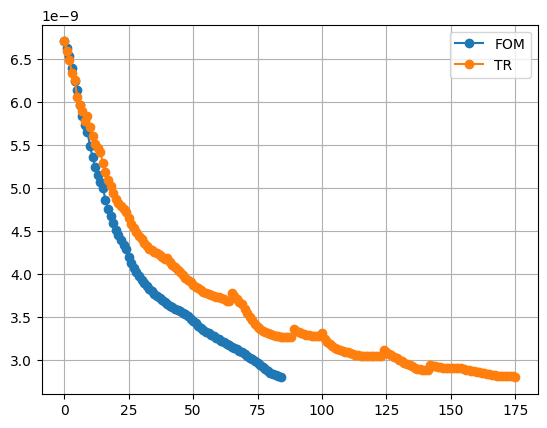

In [118]:
plt.plot(data['FOM']['J'], marker='o', label='FOM')

TR_Js = []
inner_loop_statistics = data['TR']['inner_loop_statistics']
for inner_loop_statistic in inner_loop_statistics:
    TR_Js += inner_loop_statistic['J']

plt.plot(TR_Js, marker='o', label='TR')
plt.legend()
plt.grid()

In [105]:
data['TR']['dim_Q_r']

[2, 3, 4, 5, 6, 7, 8, 9]

In [106]:
data['TR']['dim_V_r']

[91, 183, 275, 367, 459, 551, 643, 735]

In [56]:
# inner_loop_statistics = data['TR']['inner_loop_statistics']
# for inner_loop_statistic in inner_loop_statistics:
#     print(inner_loop_statistic['J'])

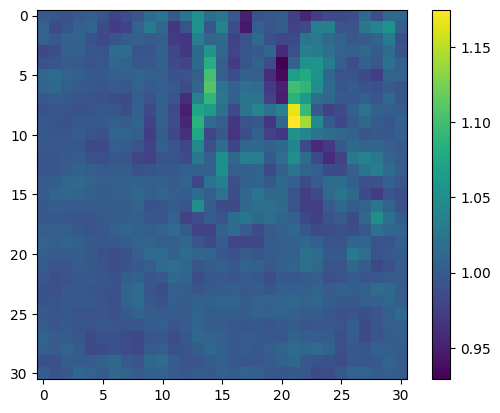

In [122]:
plt.imshow(data['FOM']['q'][-1].to_numpy().reshape((31,31)))
plt.colorbar() 

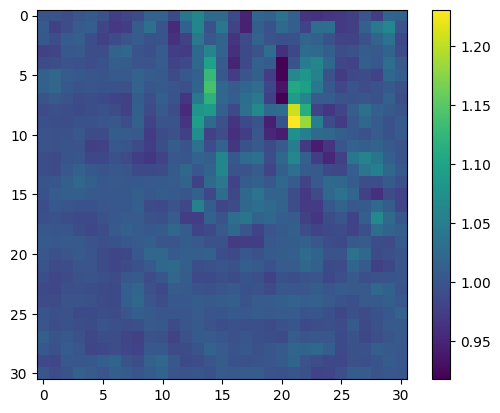

In [121]:
plt.imshow(data['TR']['q'][-1].to_numpy().reshape((31,31)))
plt.colorbar() 

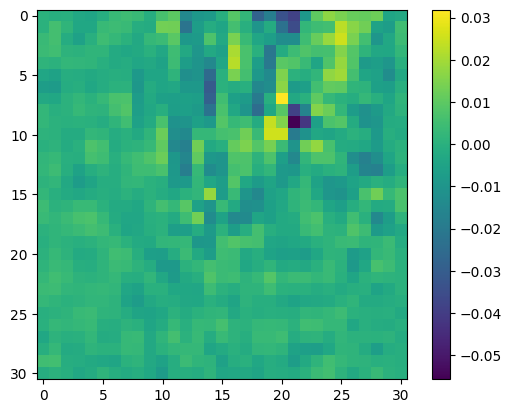

In [120]:
diff = data['FOM']['q'][-1].to_numpy().reshape((31,31)) - data['TR']['q'][-1].to_numpy().reshape((31,31))
plt.imshow(diff)
plt.title("")
plt.colorbar() 

(array([  9.,  20., 293., 516.,  72.,  31.,  11.,   5.,   2.,   2.]),
 array([0.95971421, 0.97243873, 0.98516326, 0.99788779, 1.01061231,
        1.02333684, 1.03606136, 1.04878589, 1.06151041, 1.07423494,
        1.08695946]),
 <BarContainer object of 10 artists>)

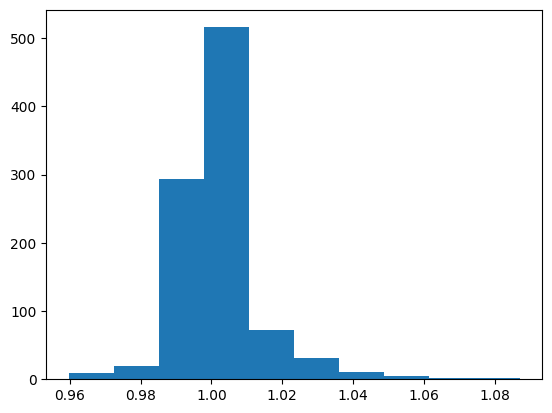

In [65]:
plt.hist(data['FOM']['q'][-1].to_numpy().flatten())

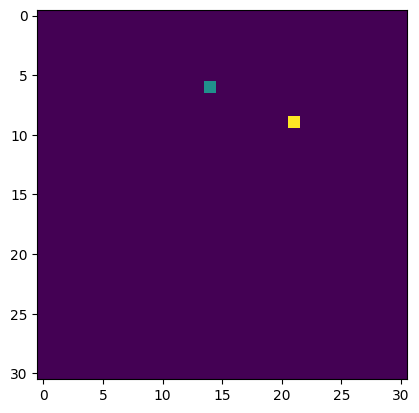

In [119]:
plt.imshow(setup['q_exact'].reshape((31,31)))

In [40]:
data['TR']['rel_est_error_nabla_J_r']

[nan, nan, nan, nan]

In [11]:
data['TR']['J']

[6.706834566982598e-09, 5.423277401771439e-09]

In [12]:
A(d(t))data['TR']['total_runtime']

[170.27885965799942]

In [73]:
data['FOM']['total_runtime']

[381.09664286201587,
 970.3112454749644,
 1537.8982901399722,
 2182.5550336799934,
 2572.2450079040136,
 3223.1586739209597,
 3623.4025731469737,
 3996.1286335740006,
 4357.4869462510105,
 5004.688996682991,
 5341.72702959599,
 5669.827724114002,
 6000.113056247006,
 6331.388485583011,
 6663.148593238962,
 7233.852234615013,
 7647.038361908984,
 8047.407826742972,
 8435.77360352996,
 8796.28760347399,
 9166.861235104967,
 9536.406456393015,
 9897.640365378,
 10311.835507892014,
 11184.194681204972,
 11653.164495731005,
 12117.292873726983,
 12589.18117455201,
 12991.87351587601,
 13382.856253292994,
 13750.21707426,
 14129.39005733101,
 14536.78488568397,
 14938.846215358994,
 15336.55011358799,
 15728.426403342979,
 16155.630387582001,
 16538.194188316003,
 16920.129211918975,
 17327.108301703003,
 17770.61664300901,
 18191.64580967097,
 18635.817054554995,
 19089.07040278497,
 19552.025413163996,
 20011.831944570993,
 20418.254594343016,
 21178.750158431998,
 21571.440788258973,
 219

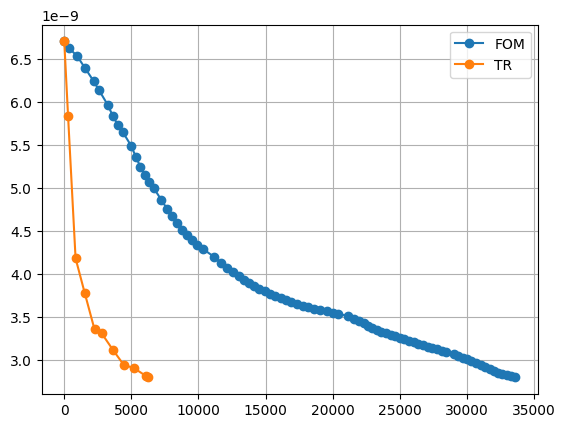

In [123]:
FOM_time = np.array([0])
FOM_time = np.append(FOM_time, data['FOM']['total_runtime'][:-1])

TR_time = np.array([0])
TR_time = np.append(TR_time, data['TR']['total_runtime'])

plt.plot(FOM_time, data['FOM']['J'], marker='o', label='FOM')
plt.plot(TR_time, data['TR']['J'], marker='o', label='TR')
plt.legend()
plt.grid()

In [117]:
FOM_time[-1] / TR_time[-1]

5.3886416959484205

In [116]:
TR_time

array([   0.        ,  281.87537163,  842.57649428, 1522.79777066,
       2256.30833836, 2791.88258994, 3645.68812381, 4434.0970234 ,
       5180.15627514, 6117.56853522, 6235.29021574])

In [77]:
FOM_time

array([    0.        ,   381.09664286,   970.31124547,  1537.89829014,
        2182.55503368,  2572.2450079 ,  3223.15867392,  3623.40257315,
        3996.12863357,  4357.48694625,  5004.68899668,  5341.7270296 ,
        5669.82772411,  6000.11305625,  6331.38848558,  6663.14859324,
        7233.85223462,  7647.03836191,  8047.40782674,  8435.77360353,
        8796.28760347,  9166.8612351 ,  9536.40645639,  9897.64036538,
       10311.83550789, 11184.1946812 , 11653.16449573, 12117.29287373,
       12589.18117455, 12991.87351588, 13382.85625329, 13750.21707426,
       14129.39005733, 14536.78488568, 14938.84621536, 15336.55011359,
       15728.42640334, 16155.63038758, 16538.19418832, 16920.12921192,
       17327.1083017 , 17770.61664301, 18191.64580967, 18635.81705455,
       19089.07040278, 19552.02541316, 20011.83194457, 20418.25459434,
       21178.75015843, 21571.44078826, 21962.37627042, 22307.84004986,
       22637.59075572, 22955.29368266, 23273.13224171, 23618.68402695,
      